In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error
from math import sqrt

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/oil_prices_2426.csv"

df = pd.read_csv(file_path)

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')
df.set_index('date', inplace=True)

df.head()

,price (dollars)
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


In [ ]:
print("Dataset shape:", df.shape)
print(df.describe())

Dataset shape: (500, 1)
       price (dollars)
count       500.000000
mean         75.873980
std          42.912398
min          16.480000
25%          35.372500
50%          64.290000
75%         111.572500
max         158.780000


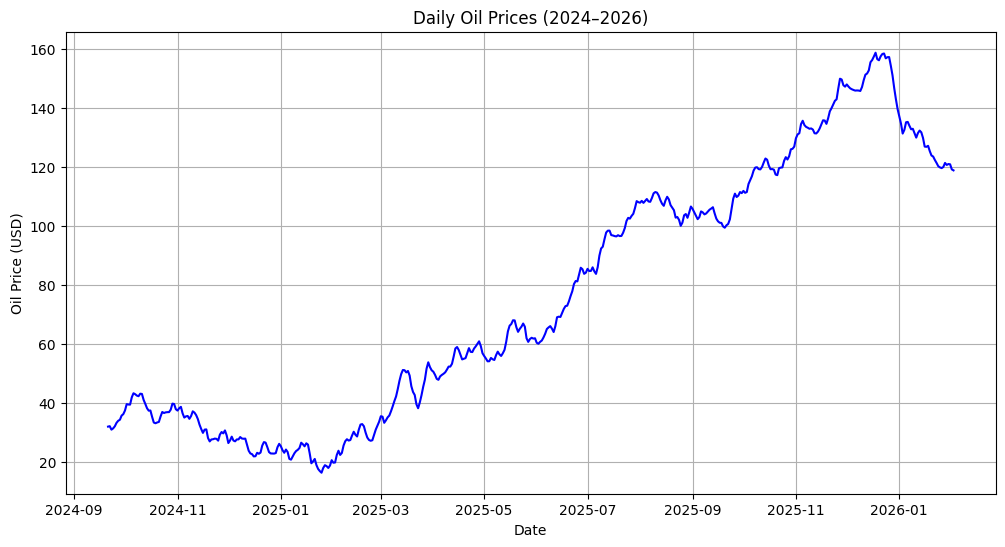

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['price (dollars)'], color='blue')

plt.title("Daily Oil Prices (2024–2026)")
plt.xlabel("Date")
plt.ylabel("Oil Price (USD)")
plt.grid(True)

plt.show()

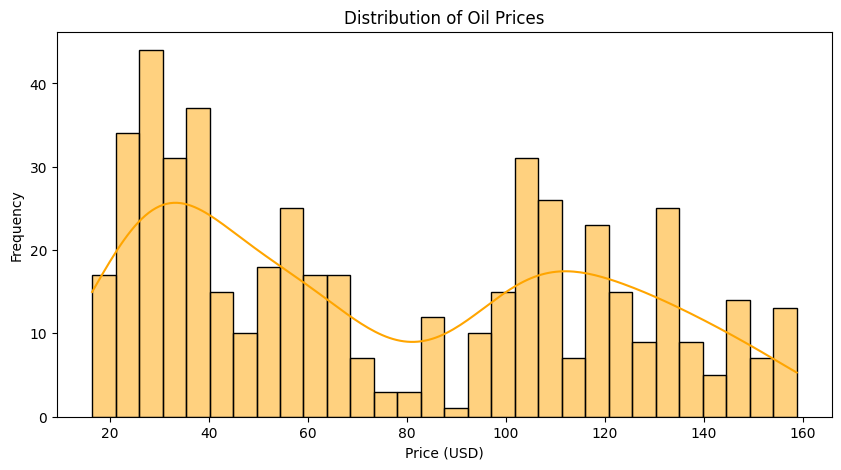

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['price (dollars)'], bins=30, kde=True, color='orange')

plt.title("Distribution of Oil Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")

plt.show()

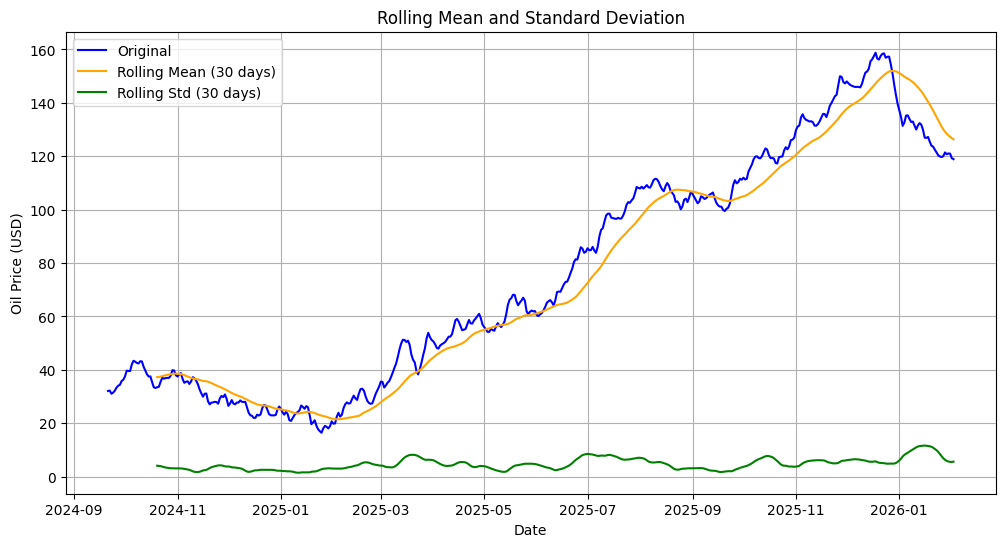

In [ ]:
# Calculate rolling statistics
rolling_mean = df['price (dollars)'].rolling(window=30).mean()
rolling_std = df['price (dollars)'].rolling(window=30).std()

# Plot
plt.figure(figsize=(12,6))

plt.plot(df['price (dollars)'], label='Original', color='blue')
plt.plot(rolling_mean, label='Rolling Mean (30 days)', color='orange')
plt.plot(rolling_std, label='Rolling Std (30 days)', color='green')

plt.title("Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Oil Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
result = adfuller(df['price (dollars)'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068
Critical Values:
1% : -3.4439899743408136
5% : -2.8675550551408353
10% : -2.569973792117904


In [ ]:
df['price_diff'] = df['price (dollars)'].diff()
df_diff = df['price_diff'].dropna()
df_diff.head()

,price_diff
date,
2024-09-22,0.15
2024-09-23,-1.18
2024-09-24,0.43
2024-09-25,0.71
2024-09-26,1.17


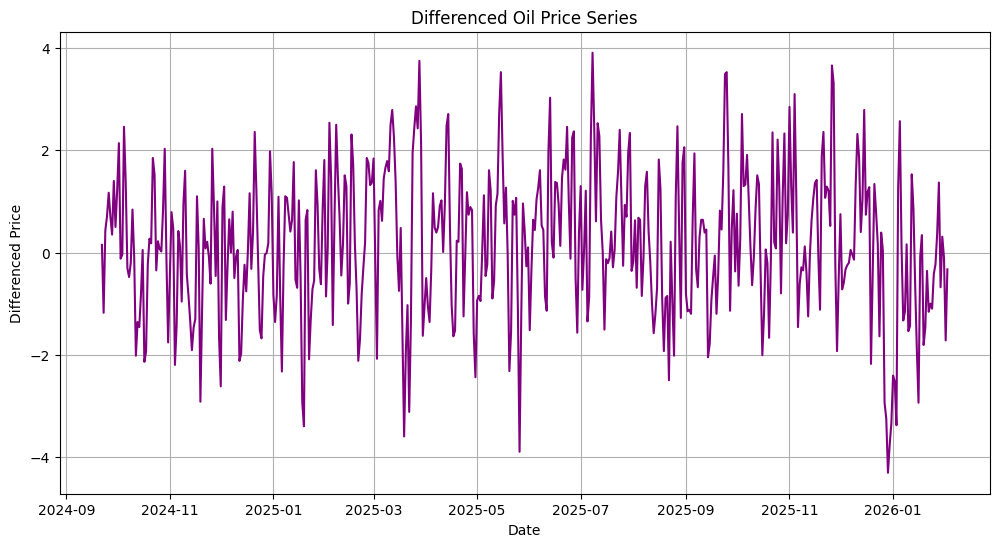

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df_diff, color='purple')

plt.title("Differenced Oil Price Series")
plt.xlabel("Date")
plt.ylabel("Differenced Price")

plt.grid(True)
plt.show()

In [ ]:
result_diff = adfuller(df_diff)

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])
print("Critical Values:")

for key, value in result_diff[4].items():
    print(key, ":", value)

ADF Statistic: -4.541460173486703
p-value: 0.00016536459860957148
Critical Values:
1% : -3.4439899743408136
5% : -2.8675550551408353
10% : -2.569973792117904


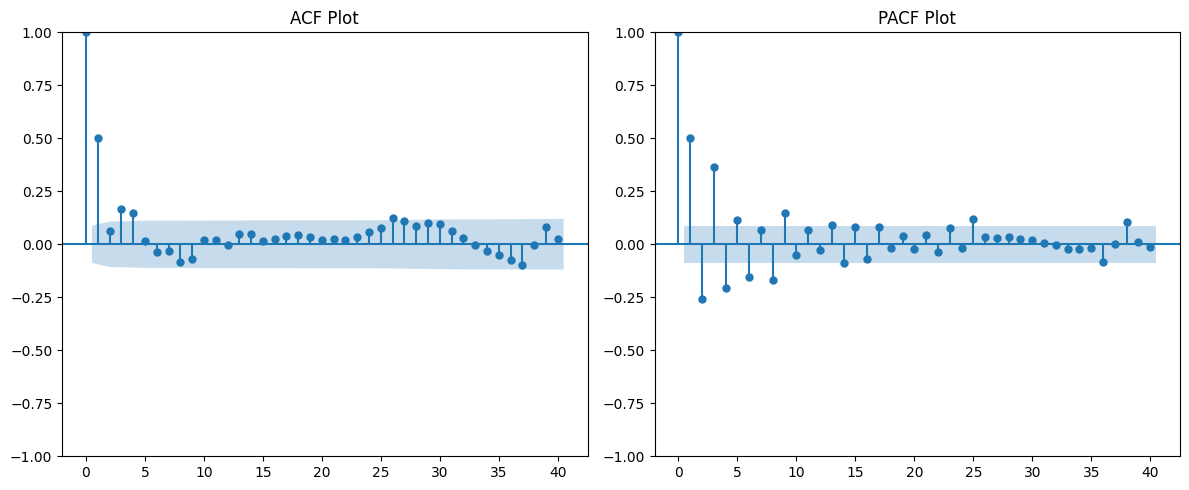

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(df_diff, lags=40, ax=plt.gca())
plt.title("ACF Plot")

plt.subplot(1,2,2)
plot_pacf(df_diff, lags=40, ax=plt.gca())
plt.title("PACF Plot")

plt.tight_layout()
plt.show()

In [ ]:
import itertools
from statsmodels.tsa.arima.model import ARIMA

p = range(0,9)
d = range(0,3)
q = range(0,9)

pdq = list(itertools.product(p,d,q))

best_aic = float("inf")
best_order = None

for param in pdq:

    try:
        model = ARIMA(df['price (dollars)'], order=param)
        results = model.fit(method_kwargs={"warn_convergence": False})

        print(f"Testing ARIMA{param} - AIC:{results.aic}")

        if results.aic < best_aic:
            best_aic = results.aic
            best_order = param

    except:
        continue

print("\nBest ARIMA order:", best_order)
print("Best AIC:", best_aic)

Testing ARIMA(0, 0, 0) - AIC:5181.098313417735
Testing ARIMA(0, 0, 1) - AIC:4497.577420954281
Testing ARIMA(0, 0, 2) - AIC:3839.976608070898
Testing ARIMA(0, 0, 3) - AIC:3314.666854574549
Testing ARIMA(0, 0, 4) - AIC:2956.7241215724184
Testing ARIMA(0, 0, 5) - AIC:2675.244698996451
Testing ARIMA(0, 0, 6) - AIC:2435.4769877766375
Testing ARIMA(0, 0, 7) - AIC:2715.251107922315
Testing ARIMA(0, 0, 8) - AIC:2813.040752973345
Testing ARIMA(0, 1, 0) - AIC:1767.5552683420601
Testing ARIMA(0, 1, 1) - AIC:1437.1703907441884
Testing ARIMA(0, 1, 2) - AIC:1438.9068821108299
Testing ARIMA(0, 1, 3) - AIC:1440.8645587856688
Testing ARIMA(0, 1, 4) - AIC:1432.2569483237498
Testing ARIMA(0, 1, 5) - AIC:1429.8979169754775
Testing ARIMA(0, 1, 6) - AIC:1431.3553757081531
Testing ARIMA(0, 1, 7) - AIC:1432.6925996514365
Testing ARIMA(0, 1, 8) - AIC:1434.229498098886
Testing ARIMA(0, 2, 0) - AIC:1754.6500301166661
Testing ARIMA(0, 2, 1) - AIC:1726.8385133417787
Testing ARIMA(0, 2, 2) - AIC:1436.4586052706059


In [ ]:
final_model = ARIMA(df['price (dollars)'], order=(2,2,7))
final_results = final_model.fit()

print(final_results.summary())

                               SARIMAX Results                                
Dep. Variable:        price (dollars)   No. Observations:                  500
Model:                 ARIMA(2, 2, 7)   Log Likelihood                -704.679
Date:                Wed, 11 Mar 2026   AIC                           1429.357
Time:                        11:12:02   BIC                           1471.463
Sample:                    09-21-2024   HQIC                          1445.882
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1824      0.032    -36.884      0.000      -1.245      -1.120
ar.L2         -0.9175      0.032    -28.331      0.000      -0.981      -0.854
ma.L1          1.1486      0.339      3.390      0.0

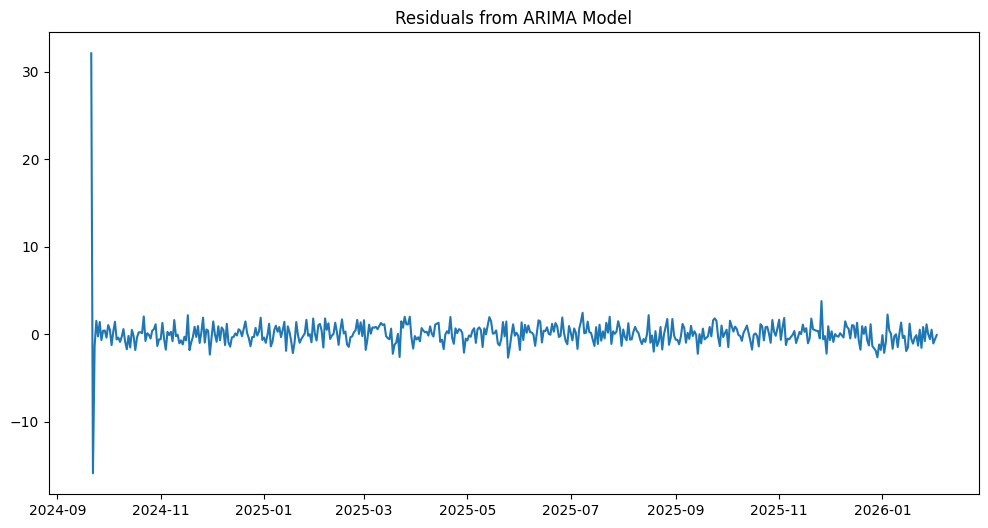

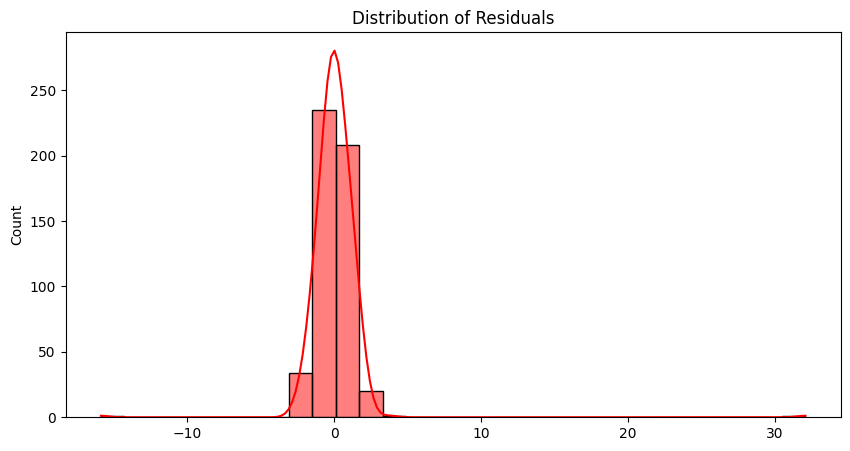

In [ ]:
residuals = final_results.resid

plt.figure(figsize=(12,6))
plt.plot(residuals)
plt.title("Residuals from ARIMA Model")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(residuals, bins=30, kde=True, color="red")
plt.title("Distribution of Residuals")
plt.show()

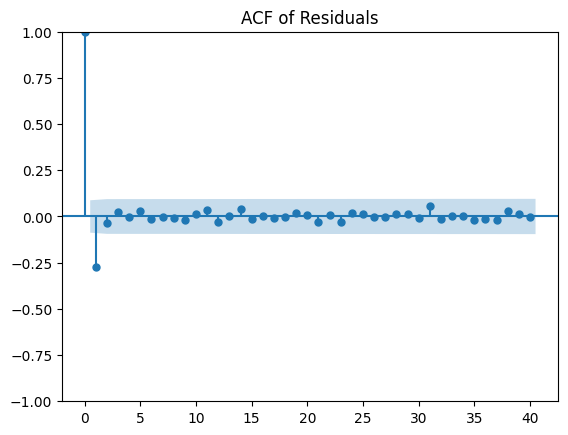

In [ ]:
plot_acf(residuals, lags=40)
plt.title("ACF of Residuals")
plt.show()

In [ ]:
train_size = int(len(df) * 0.8)
train = df['price (dollars)'][:train_size]
test = df['price (dollars)'][train_size:]
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 400
Test size: 100


In [ ]:
model_train = ARIMA(train, order=(2,2,7))
model_train_fit = model_train.fit()

In [ ]:
predictions = model_train_fit.forecast(steps=len(test))

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt

rmse = sqrt(mean_squared_error(test, predictions))

print("RMSE:", rmse)

RMSE: 14.777774938847145


In [ ]:
forecast_steps = 730

forecast = final_results.get_forecast(steps=forecast_steps)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

In [ ]:
last_date = df.index[-1]

future_dates = pd.date_range(start=last_date, periods=forecast_steps+1, freq='D')[1:]

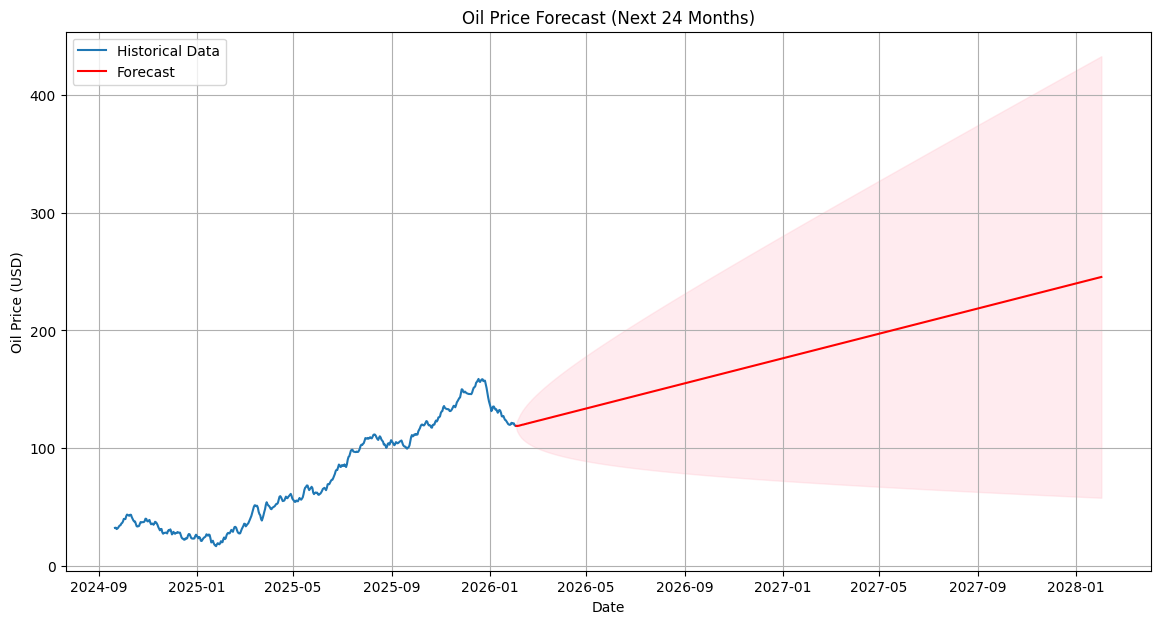

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(df.index, df['price (dollars)'], label="Historical Data")
plt.plot(future_dates, forecast_mean, label="Forecast", color="red")
plt.fill_between(future_dates,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1],
                 color="pink",
                 alpha=0.3)

plt.title("Oil Price Forecast (Next 24 Months)")
plt.xlabel("Date")
plt.ylabel("Oil Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

prophet_df = df.reset_index()[['date','price (dollars)']]
prophet_df.columns = ['ds','y']

prophet_df.head()

,ds,y
0,2024-09-21,32.10
1,2024-09-22,32.25
2,2024-09-23,31.07
3,2024-09-24,31.50
4,2024-09-25,32.21


In [ ]:

prophet_model = Prophet()

prophet_model.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future = prophet_model.make_future_dataframe(periods=730)

future.tail()

,ds
1225,2028-01-29
1226,2028-01-30
1227,2028-01-31
1228,2028-02-01
1229,2028-02-02


In [ ]:
forecast_prophet = prophet_model.predict(future)

forecast_prophet[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1225,2028-01-29,231.669435,70.008195,387.830393
1226,2028-01-30,231.740616,67.504115,390.628650
1227,2028-01-31,231.875025,68.472517,384.549135
1228,2028-02-01,232.354696,72.856022,391.524307
1229,2028-02-02,232.429716,72.607871,390.076867


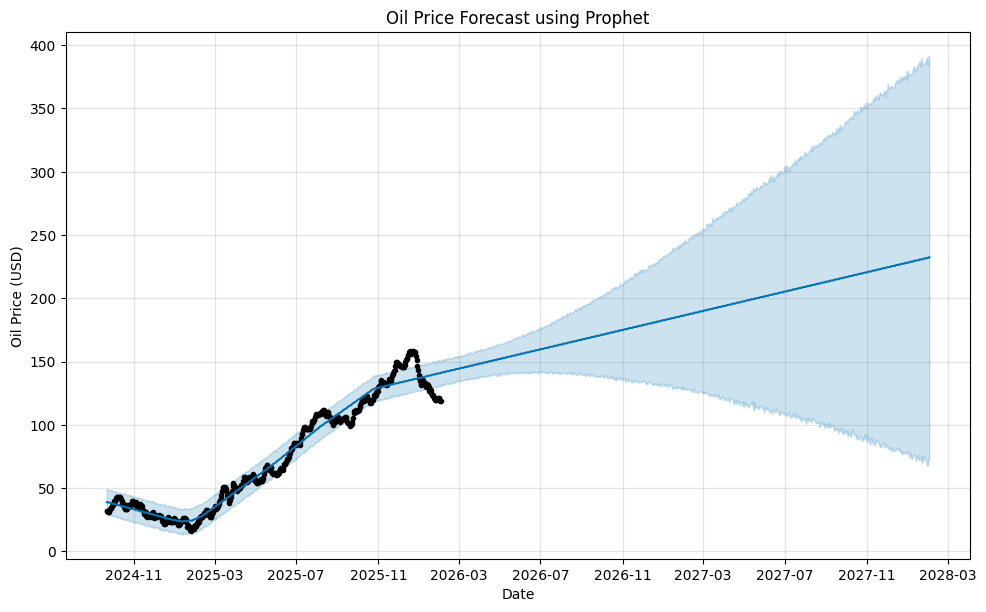

In [ ]:
fig1 = prophet_model.plot(forecast_prophet)
plt.title("Oil Price Forecast using Prophet")
plt.xlabel("Date")
plt.ylabel("Oil Price (USD)")
plt.show()

In [ ]:
train_prophet = prophet_df[:train_size]
test_prophet = prophet_df[train_size:]

prophet_model_eval = Prophet()
prophet_model_eval.fit(train_prophet)

future_test = prophet_model_eval.make_future_dataframe(periods=len(test_prophet))

forecast_test = prophet_model_eval.predict(future_test)

pred_prophet = forecast_test['yhat'][-len(test_prophet):].values

from sklearn.metrics import mean_squared_error
from math import sqrt

rmse_prophet = sqrt(mean_squared_error(test_prophet['y'], pred_prophet))

print("Prophet RMSE:", rmse_prophet)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet RMSE: 18.09736856301692
